# **Load Word2Vec Data**

In this step, we load the preprocessed Word2Vec features and their corresponding labels. Each review is represented as a numerical vector, and the shapes are printed to ensure the data is correctly loaded.

In [14]:

import numpy as np

X_train = np.load("X_train_w2v.npy")
X_val = np.load("X_val_w2v.npy")
X_test = np.load("X_test_w2v.npy")

y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (75000, 100) (75000,)
Validation: (44767, 100) (44767,)
Test: (89535, 100) (89535,)


# **Import Model and Evaluation Metrics**

In this block, we import the Logistic Regression model and the evaluation metrics that will be used to measure performance, such as accuracy, precision, recall, and F1-score.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# **Build Pipeline and Perform Hyperparameter Tuning**

In this step, we build a pipeline that includes data scaling and Logistic Regression. We test different values of the hyperparameter C to find the best configuration using the validation set.

In [16]:
C_values = [0.001, 0.01, 0.1, 1, 10]
results = []

for C in C_values:
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=C,
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    results.append({
        "model": "Logistic Regression",
        "features": "Word2Vec + Scaled",
        "C": C,
        "macro_f1": f1_score(y_val, y_val_pred, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred, average="weighted"),
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision_macro": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_val_pred, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)
results_df

,model,features,C,macro_f1,weighted_f1,accuracy,precision_macro,recall_macro
2,Logistic Regression,Word2Vec + Scaled,0.100,0.251722,0.397478,0.348605,0.267905,0.292480
3,Logistic Regression,Word2Vec + Scaled,1.000,0.251606,0.397403,0.348449,0.267928,0.292304
4,Logistic Regression,Word2Vec + Scaled,10.000,0.251452,0.397390,0.348404,0.267798,0.292049
1,Logistic Regression,Word2Vec + Scaled,0.010,0.250925,0.397345,0.348493,0.266995,0.291636
0,Logistic Regression,Word2Vec + Scaled,0.001,0.250563,0.399769,0.351531,0.265029,0.290499


# **Select Best Hyperparameter(based on Macro F1 )**

Here, we select the best value of C based on the highest Macro F1-score obtained from the validation results.

In [17]:
best_row = results_df.iloc[0]
best_C = best_row["C"]

print("Best C:", best_C)
print(best_row)

Best C: 0.1
model              Logistic Regression
features             Word2Vec + Scaled
C                                  0.1
macro_f1                      0.251722
weighted_f1                   0.397478
accuracy                      0.348605
precision_macro               0.267905
recall_macro                   0.29248
Name: 2, dtype: object


# **Train The Model Using The Best Hyperparameter**

In this step, we rebuild the model using the best value of C and train it again on the training dataset to prepare it for final evaluation.

In [18]:
final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_C,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

final_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=np.float64(0.1), class_weight='balanced',
                                    max_iter=1000, random_state=42))])

# **Evaluate on Test Set**

The trained model is evaluated on the test set to measure its performance on unseen data using multiple metrics such as Macro F1, accuracy, precision, and recall.

In [19]:
y_test_pred = final_model.predict(X_test)

test_metrics = {
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0)
}

print(test_metrics)


{'macro_f1': 0.2521231036538253, 'weighted_f1': 0.3959682652851664, 'accuracy': 0.3476964315630759, 'precision_macro': 0.2684528775025402, 'recall_macro': 0.29397572063019656}


# **Classification Report**

A detailed classification report is generated to show the performance of the model for each class individually, including precision, recall, and F1-score.

In [20]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.19      0.41      0.26      8839
           2       0.09      0.20      0.13      4923
           3       0.11      0.19      0.14      6973
           4       0.19      0.28      0.23     12680
           5       0.77      0.38      0.51     56120

    accuracy                           0.35     89535
   macro avg       0.27      0.29      0.25     89535
weighted avg       0.54      0.35      0.40     89535



# **Confusion Matrix**

The confusion matrix is plotted to visualize how the model’s predictions compare with the actual labels and to identify where misclassifications occur.

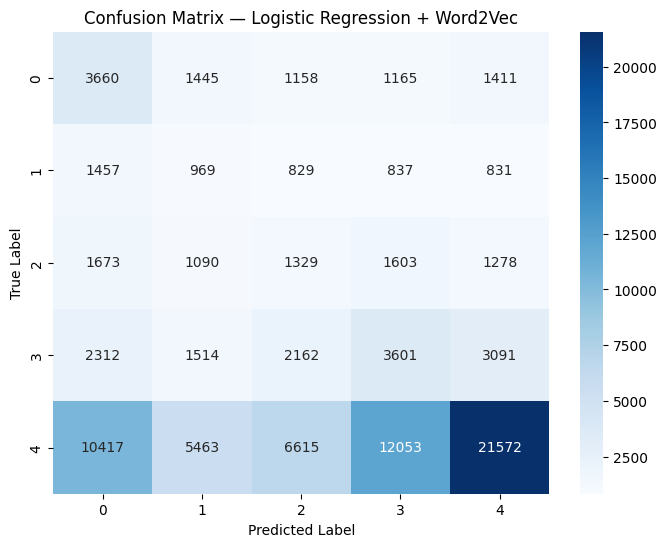

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression + Word2Vec")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# **Save The Results**

### **Validation Tuning Results**

The validation results for all tested values of C are saved to a file for comparison.

In [22]:
results_df.to_csv("results_lr_w2v_validation.csv", index=False)

### **Final Test Result**

The final evaluation results of the best model on the test set are saved for reporting and comparison with other models.

In [23]:
final_results_df = pd.DataFrame([{
    "model": "Logistic Regression",
    "features": "Word2Vec",
    "best_C": best_C,
    "macro_f1": test_metrics["macro_f1"],
    "weighted_f1": test_metrics["weighted_f1"],
    "accuracy": test_metrics["accuracy"],
    "precision_macro": test_metrics["precision_macro"],
    "recall_macro": test_metrics["recall_macro"]
}])

final_results_df.to_csv("results_lr_w2v_test.csv", index=False)

# **Conclusion**

The Logistic Regression model trained using Word2Vec features achieved moderate performance on the test set, with relatively low Macro F1-score compared to other models. While the model was able to capture general patterns in the data, it struggled to distinguish between classes effectively, particularly for the middle rating categories. This limitation is mainly due to the nature of Word2Vec representation. Although Word2Vec captures semantic similarity between words, representing each review as an average of word embeddings leads to the loss of important contextual and positional information. As a result, the model becomes less sensitive to critical sentiment cues such as negation and intensity, which are essential for accurate rating prediction. Additionally, while Logistic Regression is a strong and efficient linear classifier, its performance is highly dependent on the quality of input features. In this case, the limitation in the Word2Vec representation had a greater impact on performance than the model itself.Overall, this experiment shows that while Word2Vec provides meaningful semantic representations, it is less effective than TF-IDF for fine-grained sentiment classification tasks, especially when combined with simple averaging and linear models.